In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline
from statsmodels.stats.proportion import proportions_ztest

from sklearn.metrics import auc
import xgboost as xgb

from sklearn.model_selection import train_test_split

Dataset Loading

In [2]:
df = pd.read_csv("criteo-uplift-v2.1.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


In [4]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [5]:
print('Total number of samples: {}'.format(len(df)))

Total number of samples: 13979592


In [6]:
df['treatment'].value_counts(normalize=True)

treatment
1    0.85
0    0.15
Name: proportion, dtype: float64

Basic EDA

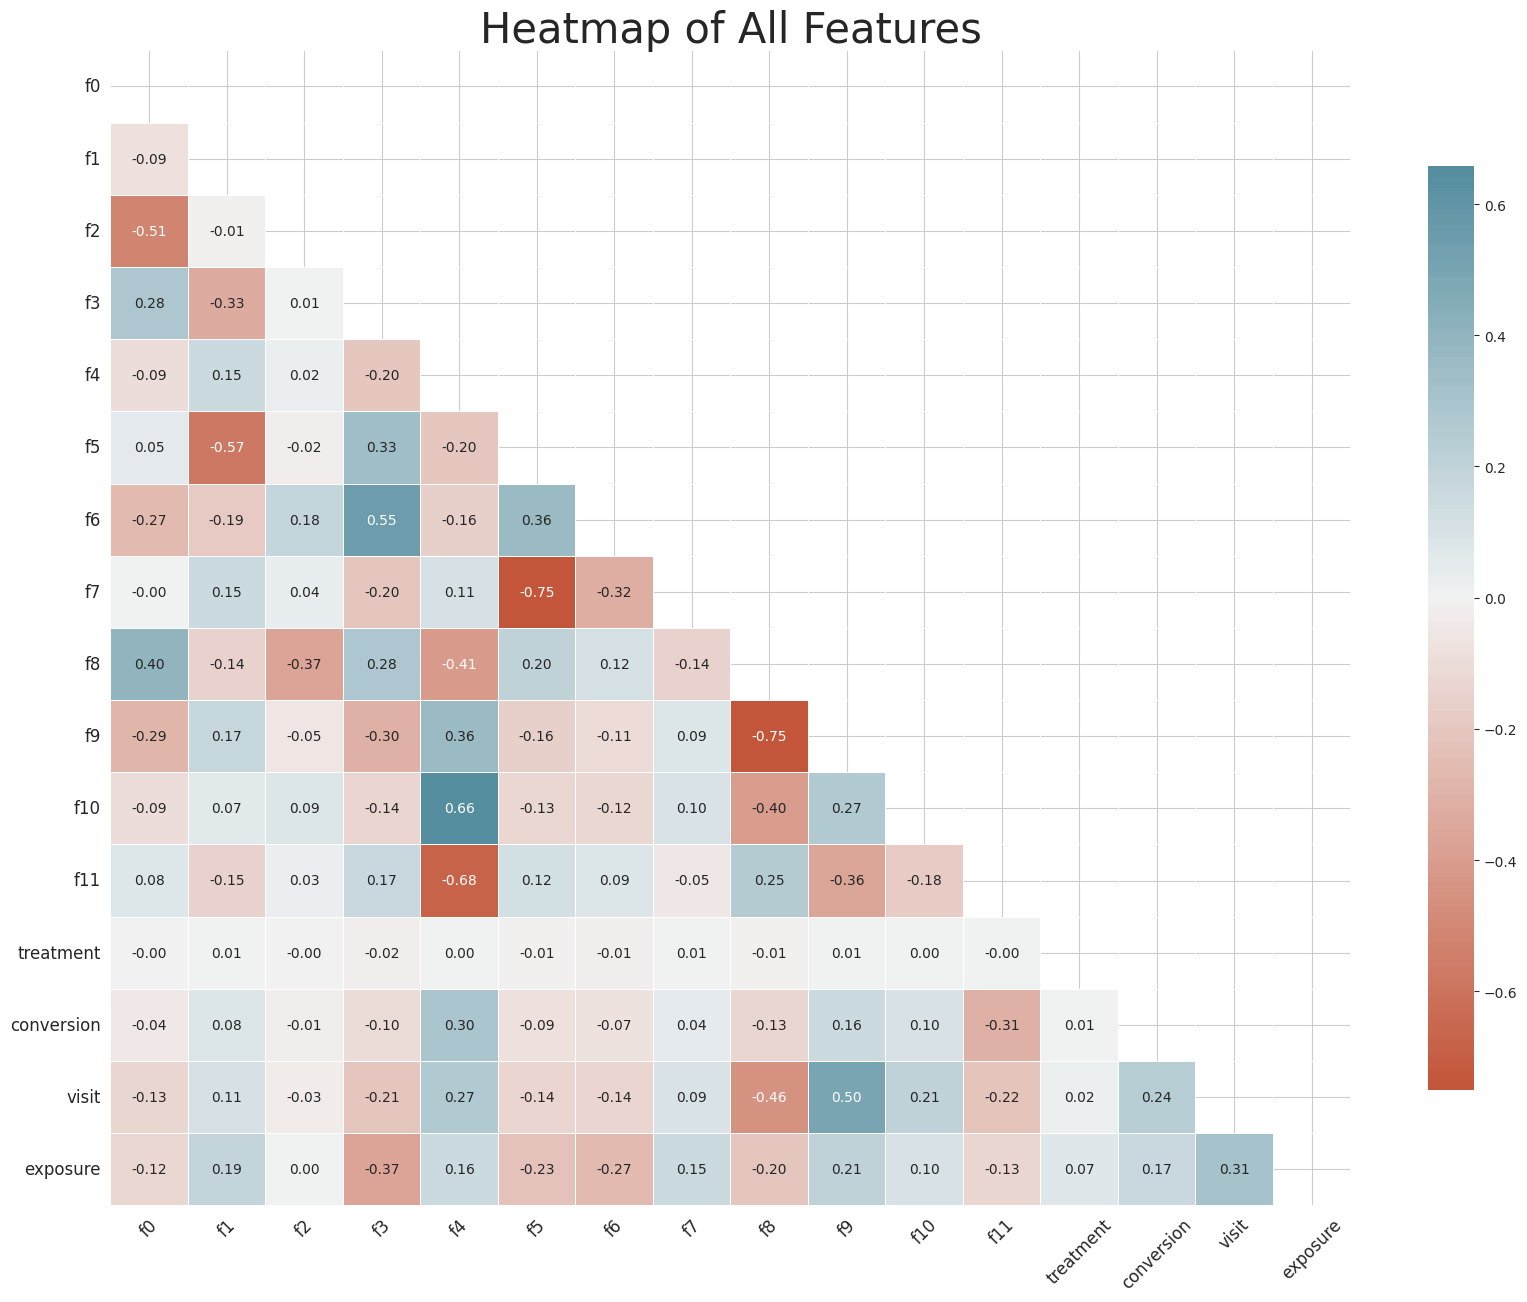

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set styles
plt.style.use('ggplot')
sns.set_style('whitegrid')

# Create figure
plt.figure(figsize=(20, 15))

# Generate a mask for the upper triangle
mask = np.zeros_like(df.corr(), dtype=bool)  # <-- changed np.bool to bool
mask[np.triu_indices_from(mask)] = True

# Plot heatmap
sns.heatmap(
    df.corr(),
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True,
    mask=mask,
    center=0,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)

# Add title
plt.title("Heatmap of All Features", fontsize=30)

# Rotate y-axis and y-axis labels
plt.yticks(rotation=0, fontsize=12)
plt.xticks(rotation=45, fontsize=12)

plt.show()

In [8]:
print('Percentage of users that visit: {}%'.format(100*round(df['visit'].mean(),4)))
print('Percentage of users that convert: {}%'.format(100*round(df['conversion'].mean(),4)))
print('Percentage of visitors that convert: {}%'.format(100*round(df[df["visit"]==1]["conversion"].mean(),4)))

Percentage of users that visit: 4.7%
Percentage of users that convert: 0.29%
Percentage of visitors that convert: 6.21%


In [9]:
vis_results_df = df.groupby('treatment').agg({'visit':['mean', 'sum', 'count']})
vis_results_df

visit                  
               mean     sum     count
treatment                            
0          0.038201   80105   2096937
1          0.048543  576824  11882655

In [10]:
con_results_df = df.groupby('treatment').agg({'conversion':['mean', 'sum', 'count']})
con_results_df

conversion                 
                mean    sum     count
treatment                            
0           0.001938   4063   2096937
1           0.003089  36711  11882655

In [11]:
print(f'Difference in clickthrough rate between control and treatment: {np.round(df.groupby("treatment")["visit"].mean()[1] - df.groupby("treatment")["visit"].mean()[0], 4)}')
print(f'Difference in conversion between control and treatment: {np.round(df.groupby("treatment")["conversion"].mean()[1] - df.groupby("treatment")["conversion"].mean()[0], 4)}')

Difference in clickthrough rate between control and treatment: 0.0103
Difference in conversion between control and treatment: 0.0012


In [12]:
proportions_ztest(count=vis_results_df[('visit', 'sum')], nobs=vis_results_df[('visit', 'count')])[1]

np.float64(0.0)

In [14]:
proportions_ztest(count=con_results_df[('conversion', 'sum')], nobs=con_results_df[('conversion', 'count')])[1]

np.float64(7.30826328583868e-179)

In [13]:
df[df['treatment']==1]['exposure'].value_counts(normalize = True)

exposure
0    0.963963
1    0.036037
Name: proportion, dtype: float64

In [14]:
vis_exp_results_df = df[df['treatment']==1].groupby('exposure').agg({'visit':['mean', 'sum', 'count']})
vis_exp_results_df

visit                  
              mean     sum     count
exposure                            
0         0.034861  399314  11454443
1         0.414538  177510    428212

In [15]:
con_exp_results_df = df[df['treatment']==1].groupby('exposure').agg({'conversion':['mean', 'sum', 'count']})
con_exp_results_df

conversion                 
               mean    sum     count
exposure                            
0          0.001194  13680  11454443
1          0.053784  23031    428212

In [16]:
proportions_ztest(count=vis_exp_results_df[('visit', 'sum')], nobs=vis_exp_results_df[('visit', 'count')])[1]

np.float64(0.0)

In [17]:
proportions_ztest(count=con_exp_results_df[('conversion', 'sum')], nobs=con_exp_results_df[('conversion', 'count')])[1]

np.float64(0.0)

In [18]:
df[df['exposure']==0].groupby('treatment').agg({'visit':['mean', 'sum', 'count']})

visit                  
               mean     sum     count
treatment                            
0          0.038201   80105   2096937
1          0.034861  399314  11454443

In [19]:
df[df['exposure']==0].groupby('treatment').agg({'conversion':['mean', 'sum', 'count']})

conversion                 
                mean    sum     count
treatment                            
0           0.001938   4063   2096937
1           0.001194  13680  11454443

Resampling

Class 0: 2096937
Class 1: 11882655
Proportion: 6 : 1


(array([0, 1]), [Text(0, 0, '1'), Text(1, 0, '0')])

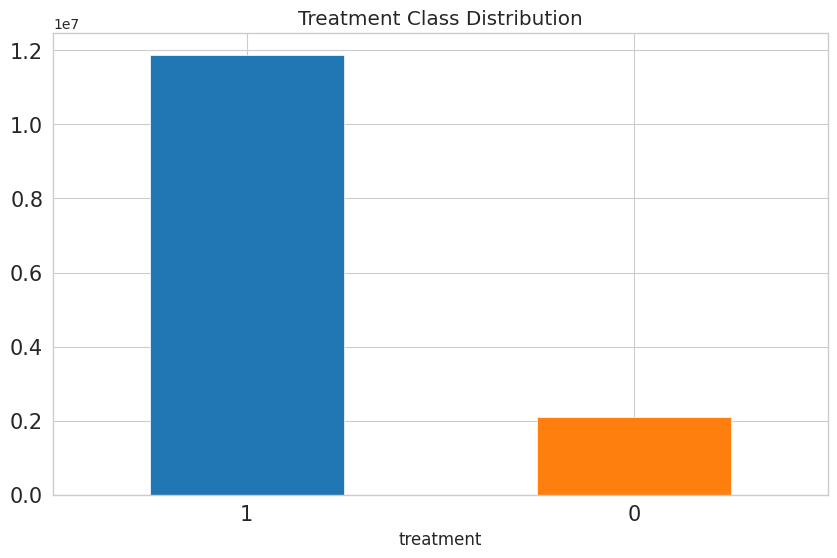

In [20]:
# bar graph for treatment class distribution
fig = plt.figure(figsize = (10,6))
target_count = df['treatment'].value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', int(round(target_count[1] / target_count[0])), ': 1')
target_count.plot(kind='bar', title='Treatment Class Distribution', color=['#2077B4', '#FF7F0E'], fontsize = 15)
plt.xticks(rotation=0)

In [21]:
train, test  = train_test_split(df, test_size=0.2, random_state=42, stratify=df['treatment'])

In [22]:
# Random Undersampling (finding the majority class and undersampling it)
def random_under(df:pd.DataFrame, feature):

    target = df[feature].value_counts()

    if target.values[0]<target.values[1]:
        under = target.index.values[1]

    else:
        under = target.index.values[0]

    df_0 = df[df[feature] != under]
    df_1 = df[df[feature] == under]

    df_treatment_under = df_1.sample(len(df_0))
    df_1 = pd.concat([df_treatment_under, df_0], axis=0)

    return df_1

In [23]:
train = random_under(train, 'treatment')

Class 0: 1677550
Class 1: 1677550
Proportion: 1 : 1


(array([0, 1]), [Text(0, 0, '1'), Text(1, 0, '0')])

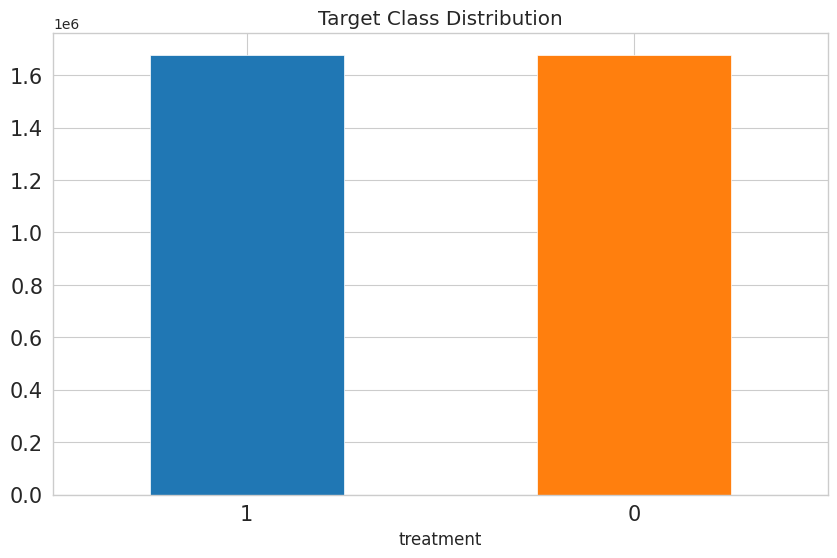

In [24]:
# bar graph for treatment distribution after resampling
fig = plt.figure(figsize = (10,6))
new_target_count = train['treatment'].value_counts()
print('Class 0:', new_target_count[0])
print('Class 1:', new_target_count[1])
print('Proportion:', int(round(new_target_count[0] / new_target_count[1])), ': 1')
new_target_count.plot(kind='bar', title='Target Class Distribution', color=['#2077B4', '#FF7F0E'], fontsize = 15)
plt.xticks(rotation=0)

Uplifting Model

In [25]:
# function to declare target class
def target_class(df, treatment, target):

    #CN:
    df['target_class'] = 0
    #CR:
    df.loc[(df[treatment] == 0) & (df[target] != 0),'target_class'] = 1
    #TN:
    df.loc[(df[treatment] != 0) & (df[target] == 0),'target_class'] = 2
    #TR:
    df.loc[(df[treatment] != 0) & (df[target] != 0),'target_class'] = 3
    return df

In [26]:
train = target_class(train.drop(columns = ['conversion', 'exposure']), 'treatment', 'visit')
test = target_class(test.drop(columns = ['conversion', 'exposure']), 'treatment', 'visit')

In [27]:
X_train = train.drop(['visit','target_class'],axis=1)
y_train = train['target_class']
X_test = test.drop(['visit','target_class'],axis=1)
y_test = test['target_class']

In [29]:
# Function to Rank the data by the uplift score
def qini_rank(uplift):
    ranked = pd.DataFrame({'ranked uplift':[], 'target_class':[]})
    ranked['target_class'] = uplift['target_class']
    ranked['uplift_score'] = uplift['uplift_score']
    ranked['ranked uplift'] = ranked.uplift_score.rank(pct=True, ascending=False)
    # Data Ranking
    ranked = ranked.sort_values(by='ranked uplift').reset_index(drop=True)
    return ranked

def qini_eval(ranked):
    uplift_model, random_model = ranked.copy(), ranked.copy()
    # Using Treatment and Control Group to calculate the uplift (Incremental gain)
    C, T = sum(ranked['target_class'] <= 1), sum(ranked['target_class'] >= 2)
    ranked['cr'] = 0
    ranked['tr'] = 0
    ranked.loc[ranked.target_class == 1,'cr'] = 1
    ranked.loc[ranked.target_class == 3,'tr'] = 1
    ranked['cr/c'] = ranked.cr.cumsum() / C
    ranked['tr/t'] = ranked.tr.cumsum() / T
    # Calculate and put the uplift and random value into dataframe
    uplift_model['uplift'] = round(ranked['tr/t'] - ranked['cr/c'],5)
    random_model['uplift'] = round(ranked['ranked uplift'] * uplift_model['uplift'].iloc[-1],5)

    uplift_model['Number_of_exposed_customers'] = np.arange(len(uplift_model))+1
    uplift_model['visits_gained'] = uplift_model.uplift*len(uplift_model)

    # Add q0
    q0 = pd.DataFrame({'ranked uplift':0, 'uplift':0, 'target_class': None}, index =[0])
    uplift_model = pd.concat([q0, uplift_model]).reset_index(drop = True)
    random_model = pd.concat([q0, random_model]).reset_index(drop = True)
    # Add model name & concat
    uplift_model['model'] = 'Uplift model'
    random_model['model'] = 'Random model'
    merged = pd.concat([uplift_model, random_model]).sort_values(by='ranked uplift').reset_index(drop = True)
    return merged, uplift_model

def uplift_curve(uplift_model):
    plt.figure(figsize = (10,6))
    # plot the data
    ax = uplift_model['visits_gained'].plot(color=['#2077B4'])
    # Plot settings
    sns.set_style('whitegrid')
    handles, labels = ax.get_legend_handles_labels()
    plt.xlabel('Number of customers treated')
    plt.ylabel('Incremental visits')
    plt.grid(True, which='major')
    return ax

def qini_plot(merged:pd.DataFrame, uplift_model:pd.DataFrame):
    gain_x = uplift_model['ranked uplift']
    gain_y = uplift_model.uplift
    qini = auc(gain_x, gain_y)
    # plot the data
    plt.figure(figsize = (10,6))
    mpl.rcParams['font.size'] = 8
    qini = auc(gain_x, gain_y)

    ax = plt.plot(gain_x, gain_y, color= '#2077B4',
        label='Normalized Uplift Model, Qini Score: {}'.format(round(qini,2)))

    plt.plot([0, gain_x.max()], [0, gain_y.max()],
        '--', color='tab:orange',
        label='Random Treatment')
    plt.legend()
    plt.xlabel('Porportion Targeted')
    plt.ylabel('Uplift')
    plt.grid(True, which='major')

    return ax

def plot_uplift(result:pd.DataFrame):
    # Function to plot the uplift curve
    ranked = qini_rank(result)
    merged, uplift_model = qini_eval(ranked)
    ax1 = uplift_curve(uplift_model)

    return ax1

def plot_qini(result:pd.DataFrame):
    # Function to plot the qini curve
    ranked = qini_rank(result)
    merged, uplift_model = qini_eval(ranked)
    ax2 = qini_plot(merged, uplift_model)

    return ax2

Training and Testing

In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
import math
import warnings
warnings.filterwarnings('ignore')

# 1) Decision Tree uplift function
def uplift_decision_tree(X_train, X_test, y_train, y_test, treatment_feature):
    result = pd.DataFrame(X_test).copy()
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train.drop(treatment_feature, axis=1), y_train)
    proba = model.predict_proba(X_test.drop(treatment_feature, axis=1))
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]
    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# 2) Random Forest uplift function
def uplift_random_forest(X_train, X_test, y_train, y_test, treatment_feature):
    result = pd.DataFrame(X_test).copy()
    model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model.fit(X_train.drop(treatment_feature, axis=1), y_train)
    proba = model.predict_proba(X_test.drop(treatment_feature, axis=1))
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]
    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# 3) XGBoost wrapper
def uplift_xgboost(X_train, X_test, y_train, y_test, treatment_feature):
    result = pd.DataFrame(X_test).copy()
    model = xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=-1)
    model.fit(X_train.drop(treatment_feature, axis=1), y_train)
    proba = model.predict_proba(X_test.drop(treatment_feature, axis=1))
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]
    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# 4) Voting Ensemble (soft voting)
def uplift_voting_ensemble(X_train, X_test, y_train, y_test, treatment_feature):
    result = pd.DataFrame(X_test).copy()
    dt = DecisionTreeClassifier(random_state=42)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=1, random_state=42)
    xgb_clf = xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=1)
    voting = VotingClassifier(
        estimators=[('dt', dt), ('rf', rf), ('xgb', xgb_clf)],
        voting='soft', n_jobs=-1
    )
    voting.fit(X_train.drop(treatment_feature, axis=1), y_train)
    proba = voting.predict_proba(X_test.drop(treatment_feature, axis=1))
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]
    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# 5) Stacking Ensemble
def uplift_stacking_ensemble(X_train, X_test, y_train, y_test, treatment_feature):
    result = pd.DataFrame(X_test).copy()
    base_estimators = [
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=1, random_state=42)),
        ('xgb', xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=1))
    ]
    final_est = LogisticRegression(max_iter=1000, solver='lbfgs')
    stack = StackingClassifier(estimators=base_estimators, final_estimator=final_est, stack_method='predict_proba', n_jobs=-1, passthrough=False)
    stack.fit(X_train.drop(treatment_feature, axis=1), y_train)
    proba = stack.predict_proba(X_test.drop(treatment_feature, axis=1))
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]
    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# 6) Blending Ensemble (custom)
def uplift_blending_ensemble(X_train, X_test, y_train, y_test, treatment_feature, meta_size=0.3):
    result = pd.DataFrame(X_test).copy()
    X_tr, X_meta, y_tr, y_meta = train_test_split(
        X_train, y_train, test_size=meta_size, random_state=42, stratify=y_train
    )
    dt = DecisionTreeClassifier(random_state=42)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=1, random_state=42)
    xgb_clf = xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=1)
    base_models = [dt, rf, xgb_clf]

    for m in base_models:
        m.fit(X_tr.drop(treatment_feature, axis=1), y_tr)

    meta_train_parts = [m.predict_proba(X_meta.drop(treatment_feature, axis=1)) for m in base_models]
    meta_train = np.hstack(meta_train_parts)
    meta_model = LogisticRegression(max_iter=2000, solver='lbfgs')
    meta_model.fit(meta_train, y_meta)

    meta_test_parts = [m.predict_proba(X_test.drop(treatment_feature, axis=1)) for m in base_models]
    meta_test = np.hstack(meta_test_parts)
    proba = meta_model.predict_proba(meta_test)

    # Simplified probability assignment
    result['p_cn'] = proba[:,0]
    result['p_cr'] = proba[:,1]
    result['p_tn'] = proba[:,2]
    result['p_tr'] = proba[:,3]

    result['uplift_score'] = result.eval('p_tr/(p_tn + p_tr) - p_cr/(p_cn + p_cr)')
    result['target_class'] = y_test
    return result

# Helper to compute Qini metrics
def compute_qini_metrics(result_df, top_pct=0.10):
    ranked = qini_rank(result_df)
    merged, uplift_model_df = qini_eval(ranked)
    gain_x = uplift_model_df['ranked uplift']
    gain_y = uplift_model_df.uplift
    qini = auc(gain_x, gain_y)
    n = len(uplift_model_df) - 1
    top_n = max(1, int(np.ceil(top_pct * n)))
    uplift_top_sum = uplift_model_df['uplift'].iloc[1: top_n+1].sum()
    visits_gained_top = uplift_top_sum * len(uplift_model_df)
    return {
        'qini': qini,
        f'gain_top_{int(top_pct*100)}%': visits_gained_top
    }

In [32]:
# This list will store the final performance metrics for each model.
metrics_summary = []

Running model: Decision Tree ...
  -> Qini: nan | Gain@Top10%: 186418329.4696


13699

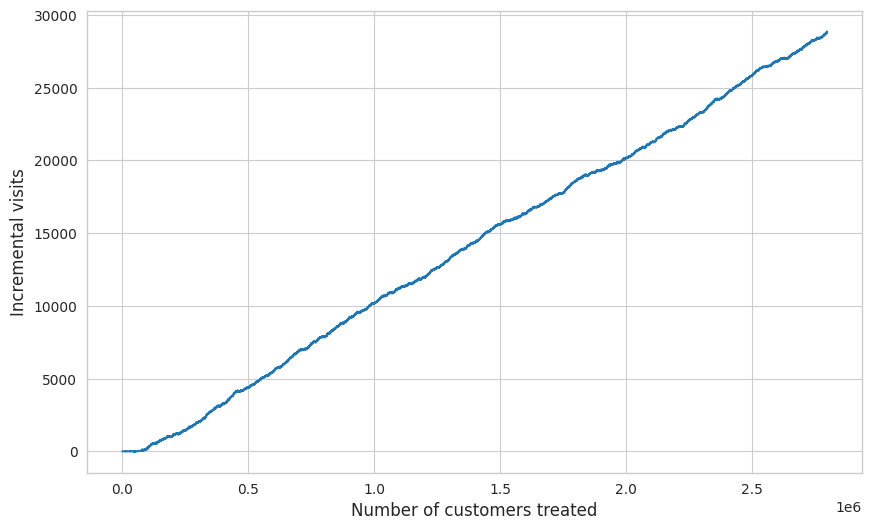

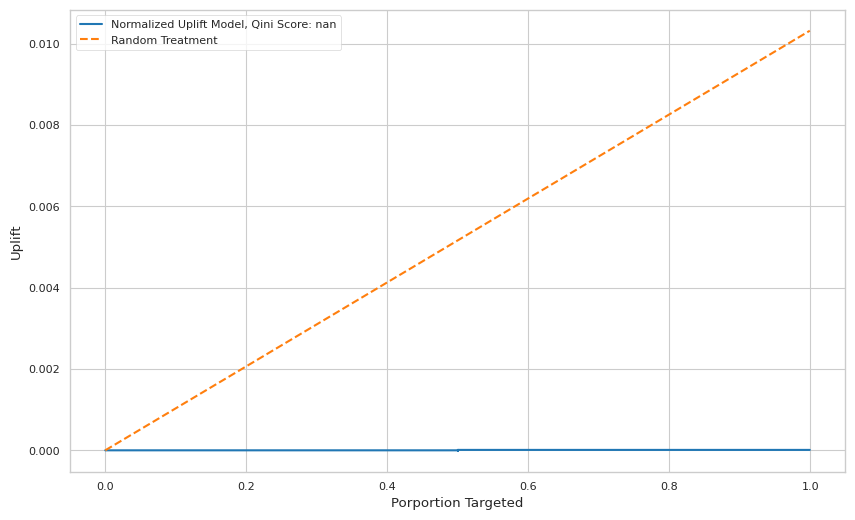

In [32]:
import gc

print("Running model: Decision Tree ...")
# Train model
res_dt = uplift_decision_tree(X_train, X_test, y_train, y_test, 'treatment')
# Compute metrics
m_dt = compute_qini_metrics(res_dt, top_pct=0.10)
# Append summary to our list
metrics_summary.append({'model': 'Decision Tree', **m_dt})

print(f"  -> Qini: {m_dt['qini']:.4f} | Gain@Top10%: {m_dt['gain_top_10%']:.4f}")

plot_uplift(res_dt)
plot_qini(res_dt)

# Clean up memory
del res_dt, m_dt
gc.collect()

Running model: Random Forest ...
  -> Qini: 0.0098 | Gain@Top10%: 5195532319.6000


6455

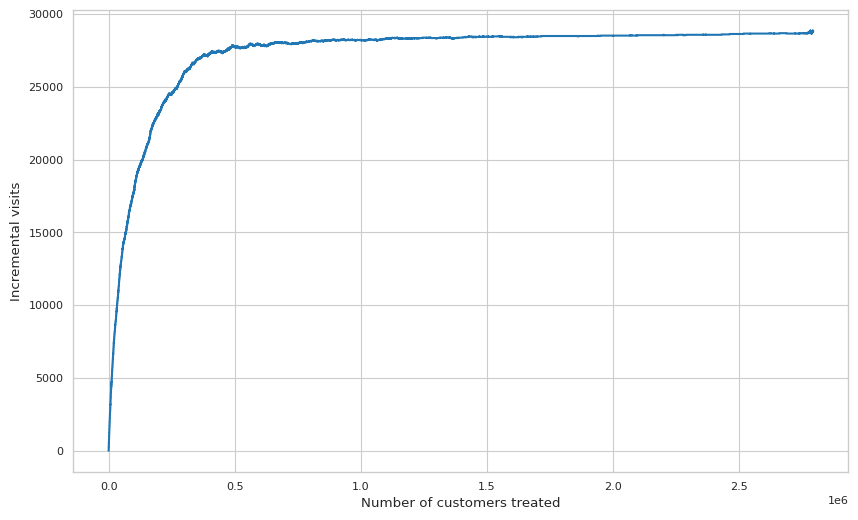

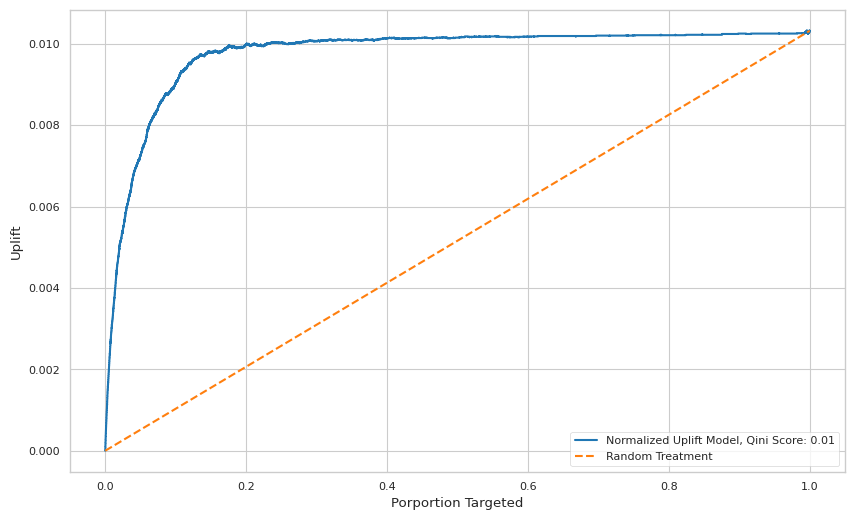

In [33]:
import gc

print("Running model: Random Forest ...")
res_rf = uplift_random_forest(X_train, X_test, y_train, y_test, 'treatment')
m_rf = compute_qini_metrics(res_rf, top_pct=0.10)
metrics_summary.append({'model': 'Random Forest', **m_rf})

print(f"  -> Qini: {m_rf['qini']:.4f} | Gain@Top10%: {m_rf['gain_top_10%']:.4f}")

plot_uplift(res_rf)
plot_qini(res_rf)

del res_rf, m_rf
gc.collect()

Running model: XGBoost ...
  -> Qini: 0.0091 | Gain@Top10%: 4617247153.3440


6437

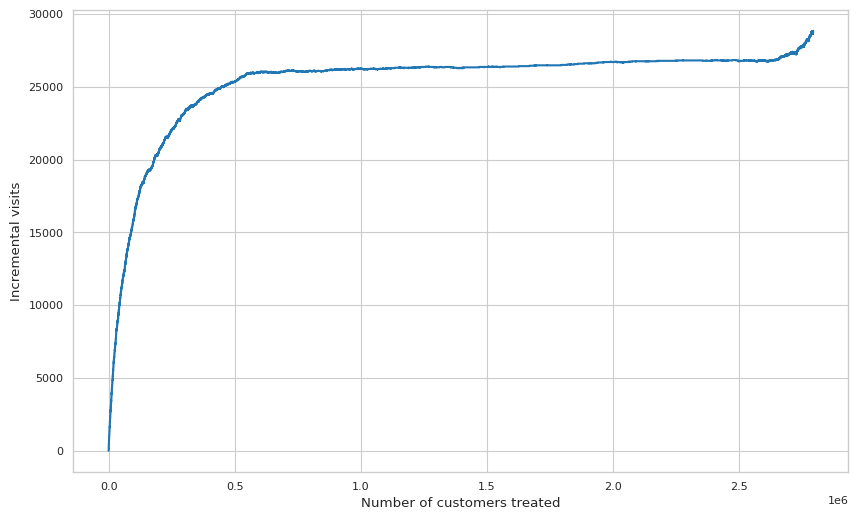

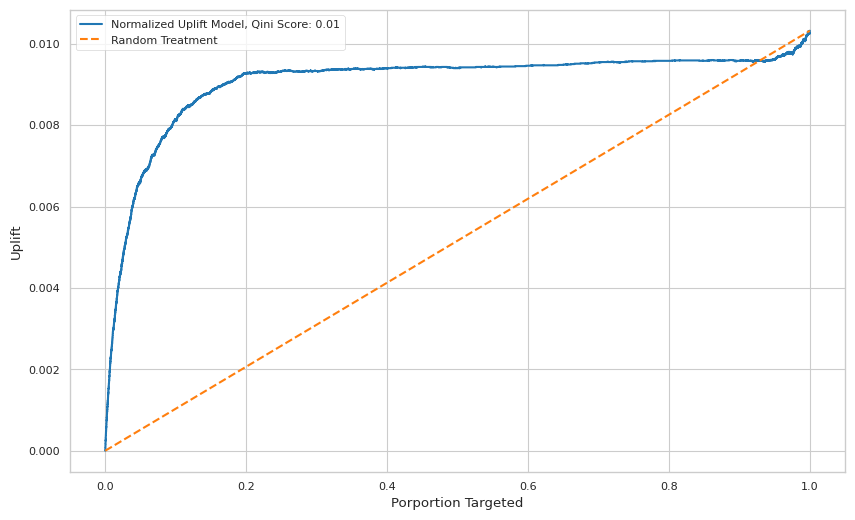

In [34]:
import gc

print("Running model: XGBoost ...")
res_xgb = uplift_xgboost(X_train, X_test, y_train, y_test, 'treatment')
m_xgb = compute_qini_metrics(res_xgb, top_pct=0.10)
metrics_summary.append({'model': 'XGBoost', **m_xgb})

print(f"  -> Qini: {m_xgb['qini']:.4f} | Gain@Top10%: {m_xgb['gain_top_10%']:.4f}")

plot_uplift(res_xgb)
plot_qini(res_xgb)

del res_xgb, m_xgb
gc.collect()

Running model: Voting Ensemble ...
  -> Qini: 0.0062 | Gain@Top10%: 2948856152.9792


6452

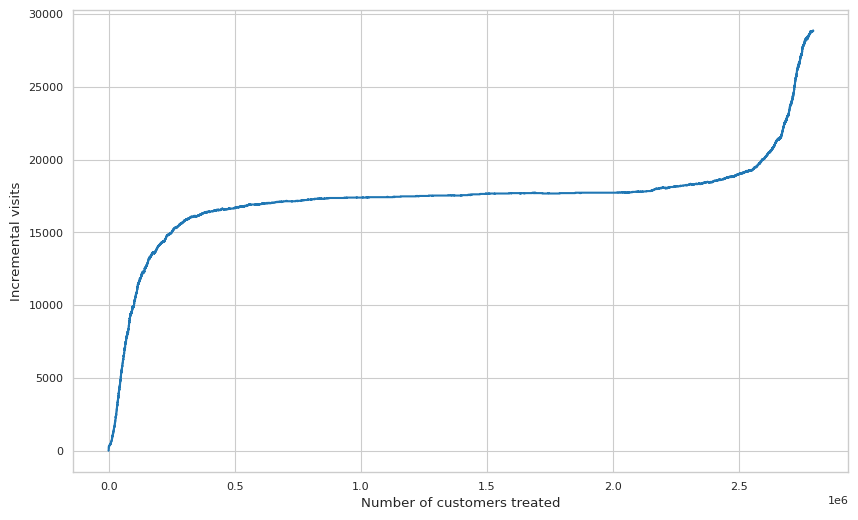

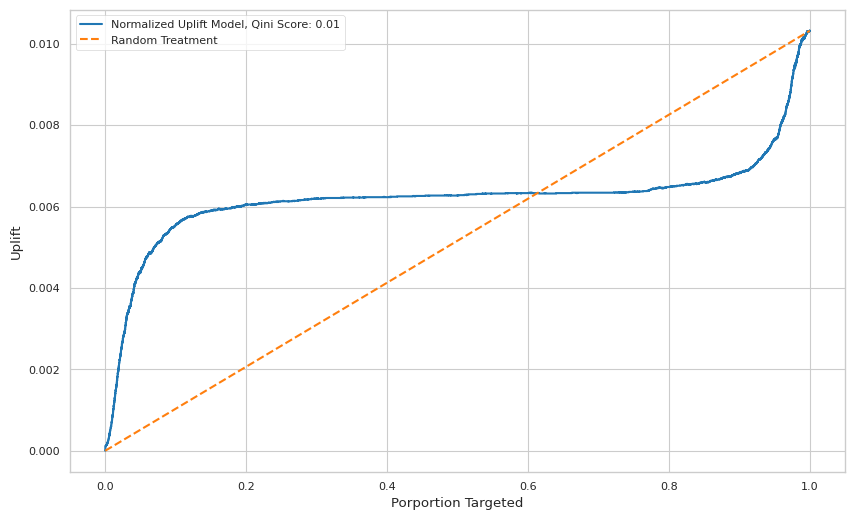

In [35]:
import gc

print("Running model: Voting Ensemble ...")
res_vot = uplift_voting_ensemble(X_train, X_test, y_train, y_test, 'treatment')
m_vot = compute_qini_metrics(res_vot, top_pct=0.10)
metrics_summary.append({'model': 'Voting Ensemble', **m_vot})

print(f"  -> Qini: {m_vot['qini']:.4f} | Gain@Top10%: {m_vot['gain_top_10%']:.4f}")

plot_uplift(res_vot)
plot_qini(res_vot)

del res_vot, m_vot
gc.collect()

In [ ]:
import gc

print("Running model: Stacking Ensemble ...")
res_stk = uplift_stacking_ensemble(X_train, X_test, y_train, y_test, 'treatment')
m_stk = compute_qini_metrics(res_stk, top_pct=0.10)
metrics_summary.append({'model': 'Stacking Ensemble', **m_stk})

print(f"  -> Qini: {m_stk['qini']:.4f} | Gain@Top10%: {m_stk['gain_top_10%']:.4f}")

plot_uplift(res_stk)
plot_qini(res_stk)

del res_stk, m_stk
gc.collect()

Running model: Stacking Ensemble ...


In [ ]:
import gc

print("Running model: Blending Ensemble ...")
res_bld = uplift_blending_ensemble(X_train, X_test, y_train, y_test, 'treatment')
m_bld = compute_qini_metrics(res_bld, top_pct=0.10)
metrics_summary.append({'model': 'Blending Ensemble', **m_bld})

print(f"  -> Qini: {m_bld['qini']:.4f} | Gain@Top10%: {m_bld['gain_top_10%']:.4f}")

plot_uplift(res_bld)
plot_qini(res_bld)

del res_bld, m_bld
gc.collect()

In [ ]:
# Create a comparison dataframe from the collected metrics
comp_df = pd.DataFrame(metrics_summary)
comp_df = comp_df.sort_values(by='qini', ascending=False).reset_index(drop=True)

print('\nModel comparison (sorted by Qini score):')
print(comp_df)

# Recommend best model (highest Qini)
best_model_name = comp_df.iloc[0]['model']
best_model_qini = comp_df.iloc[0]['qini']
best_model_gain = comp_df.iloc[0]['gain_top_10%']

print('\n-----------------------------------------')
print('BEST MODEL based on Qini score:')
print(f"Model: {best_model_name}  |  Qini: {best_model_qini:.4f}  |  Gain@Top10%: {best_model_gain:.4f}")
print('-----------------------------------------\n')


# Now, re-run only the best model to get its data for plotting and inspection
print(f"Re-running the best model ({best_model_name}) for detailed analysis...")

# Dictionary to easily call the best model's function
models_map = {
    'Decision Tree': uplift_decision_tree,
    'Random Forest': uplift_random_forest,
    'XGBoost': uplift_xgboost,
    'Voting Ensemble': uplift_voting_ensemble,
    'Stacking Ensemble': uplift_stacking_ensemble,
    'Blending Ensemble': uplift_blending_ensemble
}

best_model_func = models_map[best_model_name]
best_model_results = best_model_func(X_train, X_test, y_train, y_test, 'treatment')

# We need qini_eval again for plotting
ranked_best = qini_rank(best_model_results)
_, uplift_df_best = qini_eval(ranked_best)

# Plot the final uplift curve for the best model
print(f"\nPlotting uplift curve for best model: {best_model_name}")
plt.figure(figsize=(10, 6))
plt.plot(uplift_df_best['ranked uplift'], uplift_df_best['uplift'], label=f"{best_model_name} uplift")
plt.plot([0, uplift_df_best['ranked uplift'].max()], [0, uplift_df_best['uplift'].max()], '--', label='Random')
plt.xlabel('Proportion Targeted')
plt.ylabel('Uplift')
plt.title(f"Qini Curve - {best_model_name} (Qini={best_model_qini:.3f})")
plt.legend()
plt.grid(True)
plt.show()

# Show the result DataFrame head for the best model
print("\nSample predictions (probabilities + uplift score) for best model:")
display(best_model_results.head())